<a href="https://colab.research.google.com/github/LuisManuelCatzoliSoriano/Procesos-Estoc-sticos/blob/main/PDT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$$Q=\begin{pmatrix}
-2 & 2 & 0 \\
3 & -4 & 1 \\
0.5 & 0 & -0.5 \\
\end{pmatrix}$$

$P(t)=e^{-tQ}$

Modelo: $S=\left\{0,1,2 \right\}$

Estado $0$: Servidor libre.

Estado $1$: Servidor ocupado.

Estado $2$: Servidor caído.

1. Calcular $P(t)$ en sympy

In [52]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [53]:
Q=sp.Matrix([[-2,2,0],
            [3,-4,1],
            [0.5,0,-0.5]])

In [54]:
t=sp.symbols('t')

P=sp.exp(t*Q)

Pb=sp.simplify(P.subs(t,1))

Pb

Matrix([
[0.519803932175414, 0.274932864130501, 0.205263203694086],
[0.463715097119272, 0.244871068044913, 0.291413834835815],
[ 0.24833851926495, 0.102631601847043, 0.649029878888007]])

1. Si el sistema inicia libre, ¿Cuál es la probabilidad de estar caído después de $t=1$?

$$P(x(s+t)=2|x(s)=0)=0.205263203694086$$

2. ¿Cómo cambia $P(t)$ cuando $t\to \infty$?

In [55]:
P

Matrix([
[ 0.4 + 0.310599978800064*exp(-5.60849528301415*t) + 0.289400021199936*exp(-0.891504716985849*t),  0.2 - 0.386199427601717*exp(-5.60849528301415*t) + 0.186199427601717*exp(-0.891504716985849*t),  0.4 + 0.0755994488016536*exp(-5.60849528301415*t) - 0.475599448801654*exp(-0.891504716985849*t)],
[ 0.4 - 0.560399279202162*exp(-5.60849528301415*t) + 0.160399279202162*exp(-0.891504716985849*t),  0.2 + 0.696799406401781*exp(-5.60849528301415*t) + 0.103200593598219*exp(-0.891504716985849*t),   0.4 - 0.136400127199618*exp(-5.60849528301415*t) - 0.263599872800382*exp(-0.891504716985849*t)],
[0.4 - 0.0304003391989824*exp(-5.60849528301415*t) - 0.369599660801018*exp(-0.891504716985849*t), 0.2 + 0.0377997244008268*exp(-5.60849528301415*t) - 0.237799724400827*exp(-0.891504716985849*t), 0.4 - 0.00739938520184439*exp(-5.60849528301415*t) + 0.607399385201844*exp(-0.891504716985849*t)]])

Q=$$Q=\begin{pmatrix}
0.4 & 0.2 & 0.4 \\
0.4 & 0.2 & 0.4 \\
0.4 & 0.2 & 0.4 \\
\end{pmatrix}$$

Graficar $P_{00}(t)$, $P_{01}(t)$ y $P_{02}(t)$

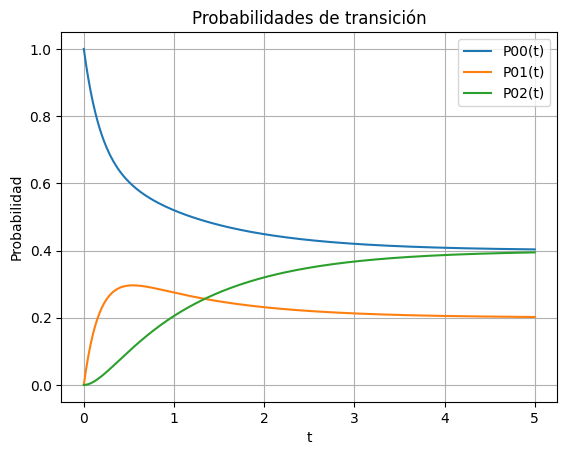

In [57]:
from scipy.linalg import expm

t_values = np.linspace(0, 5, 200)
P00 = []
P01 = []
P02 = []

for t in t_values:
    P = expm(t * Q)

    P00.append(P[0,0])
    P01.append(P[0,1])
    P02.append(P[0,2])

plt.plot(t_values, P00, label='P00(t)')
plt.plot(t_values, P01, label='P01(t)')
plt.plot(t_values, P02, label='P02(t)')

plt.xlabel('t')
plt.ylabel('Probabilidad')
plt.title('Probabilidades de transición')
plt.legend()
plt.grid(True)

plt.show()

4. Simular algunas trayectorias y comparar con los resultados analíticos.

In [58]:
import random as r
from os import chmod

In [65]:
def markov(a, P, n):
    m = len(P)          # número de estados
    S = list(range(m))  # estados en lista

    x0 = r.choices(S, weights=a, k=1)[0] #Regresa una lista, por eso se pone [0] para extraer un número
    cadena = [x0]

    for i in range(n):
        p = P[x0] # renglón de transición
        x1 = r.choices(S, weights=p, k=1)[0]

        cadena.append(x1)

        x0 = x1
    return cadena

In [66]:
a=[1,0,0]
n=10
markov(a, P, n)

[0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0]

In [ ]:
def simulacion(n):
  L=[]
  for i in range(n):
    markov(a, P, n)
    L.append(markov(a, P, n))
  return L